<a href="https://colab.research.google.com/github/MariaBessa1/Computacao_Cientifica/blob/master/Exercicio_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PARTE 1

##Derivadas da função Cosseno f(x) = cos(x):

f'(x) = -sen(x):

f''(x) = -cos(x):

f'''(x) = sen(x):

f''''(x) = cos(x):


##Avaliando quando x == 0:


f(0) = cos(0) = 1

f'(0) = -sen(0) = 0

f''(0) = -cos(0) = -1

f'''(0) = sen(0) = 0

f''''(0) = cos(0) = 1

##Os termos com potência ímpar somem, nos permitindo então escrever a série de Taylor da função cosseno como:

                            Cos(x) = 1 - (x^2)/2! + (x^4)/4! - (x^6)/6! + ...


##Implementando...

In [4]:
import math
import numpy as np

def cosseno(x, n):
    soma = 0

    for i in range(n):
        fator = 2*i

        sinal = np.power(-1, i)
        numerador = np.power(x, fator)
        denominador = math.factorial(fator)

        soma += sinal * numerador / denominador

    return soma

In [81]:
print("Série de Taylor Cosseno")
print(cosseno(np.pi/3, 10)) ##colocando um valor relativamente alto no N para maior semelhança.
print(cosseno(np.pi/3, 2)) ##Com um valor menor, não há precisão.

print("\nFunção Cosseno Numpy")
print(np.cos(np.pi/3))

Série de Taylor Cosseno
0.5000000000000001
0.45168864438392464

Função Cosseno Numpy
0.5000000000000001


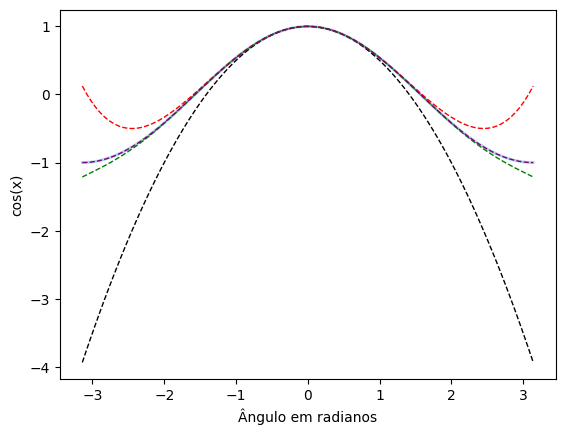

In [76]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-np.pi, np.pi, 100)

y1 = np.cos(x)
y2 = cosseno(x, 2)
y3 = cosseno(x, 3)
y4 = cosseno(x, 4)
y5 = cosseno(x, 5)

fig, ax = plt.subplots()

ax.plot(x, y1, linewidth=2.0, color='lightblue')
ax.plot(x, y2, linewidth=1.0, color='black', linestyle='dashed')
ax.plot(x, y3, linewidth=1.0, color='red', linestyle='dashed')
ax.plot(x, y4, linewidth=1.0, color='green', linestyle='dashed')
ax.plot(x, y5, linewidth=1.0, color='purple', linestyle='dashed')

ax.set_xlabel('Ângulo em radianos')
ax.set_ylabel('cos(x)')

plt.show()

Aqui, podemos analisar inicialmente que quanto maior o valor de N, maior a semelhança da série de Taylor com a função original cos(x).

#PARTE 2

##Série de Taylor do Cosseno Otimizada:

In [7]:
def cosseno_otimizado(x, n):

    numerador = 1
    denominador = 1

    soma = 1
    sinal = 1

    for i in range(1, n):

        fator = 2*i

        sinal = -1 * sinal

        numerador = x*x*numerador

        denominador = fator * (fator-1) * denominador

        soma += sinal * numerador / denominador

    return soma

In [8]:
cosseno_otimizado(np.pi/3, 3) #Mesmo resultado do Não Otimizado

0.501796201500181

###Qual faixa de valor de x a série de Taylor é correta? Qual valor de n escolhido?

A Série de Taylor do cosseno converge para todos os valores reais de (x). Para a análise solicitada computacionalmente, foi utilizado o intervalo de -π e π, seguindo o exemplo apresentado para o seno. Dessa forma, é possível testar o  erro máximo para cada valor de N entre nossa série de Taylor otimizada e a função do Cos(x) do Numpy. Podemos então observar como o aumento do número de termos influencia a precisão da aproximação.

In [71]:
 ##Calcula todos os valores de X para cada N e retorna o PIOR erro (em relacao a cos(x) do numpy e a taylor) em cada N
x = np.linspace(-np.pi, np.pi, 100)

for n in range(2, 15):

    aproximacao = np.array([
        cosseno_otimizado(valor, n)
        for valor in x
    ])

    erro = np.max(
        np.abs(np.cos(x) - aproximacao)
    )

    print(f"N = {n} | erro máximo = {erro}")

N = 2 | erro máximo = 2.934802200544679
N = 3 | erro máximo = 1.1239099258720886
N = 4 | erro máximo = 0.21135284298250068
N = 5 | erro máximo = 0.023977787376392445
N = 6 | erro máximo = 0.0018291040136215742
N = 7 | erro máximo = 0.0001004702957823067
N = 8 | erro máximo = 4.16780914247461e-06
N = 9 | erro máximo = 1.352604445115091e-07
N = 10 | erro máximo = 3.5290801392307003e-09
N = 11 | erro máximo = 7.565070792026063e-11
N = 12 | erro máximo = 1.3564704914870163e-12
N = 13 | erro máximo = 2.042810365310288e-14
N = 14 | erro máximo = 4.440892098500626e-16


Os testes mostraram que o erro diminui conforme o número de termos N aumenta.

##Tabela

#PARTE 3


##Utilizando a série de Taylor com precisão de N até 20:


Para a realização dessa etapa, utilizamos o memso código elaborado para a parte 2, com a alteração do valor de N e o intervalo utilizado em X (para poder observar outros resultados)



###Cálculo erro máximo dentro de cada N (2 ate 20)

In [74]:
##Calcula todos os valores de X para cada N e retorna o PIOR erro (em relacao a cos(x) do numpy e a taylor) em cada N
x = np.linspace(-np.pi, np.pi, 100)

x = np.arange(-5, 6, dtype=float)

for n in range(2, 21):

    aproximacao = np.array([
        cosseno_otimizado(valor, n)
        for valor in x
    ])

    erro = np.max(
        np.abs(np.cos(x) - aproximacao)
    )

    print(f"N = {n} | erro máximo = {erro}")

N = 2 | erro máximo = 11.783662185463227
N = 3 | erro máximo = 14.258004481203441
N = 4 | erro máximo = 7.443384407685448
N = 5 | erro máximo = 2.244735631997092
N = 6 | erro máximo = 0.4464088234702804
N = 7 | erro máximo = 0.0632776264288431
N = 8 | erro máximo = 0.00673424855730026
N = 9 | erro máximo = 0.0005586550870896878
N = 10 | erro máximo = 3.717037405326362e-05
N = 11 | erro máximo = 2.0286694429882957e-06
N = 12 | erro máximo = 9.249091936780474e-08
N = 13 | erro máximo = 3.576126006432645e-09
N = 14 | erro máximo = 1.1876033489954807e-10
N = 15 | erro máximo = 3.425038030968608e-12
N = 16 | erro máximo = 8.604228440844963e-14
N = 17 | erro máximo = 2.4424906541753444e-15
N = 18 | erro máximo = 5.551115123125783e-16
N = 19 | erro máximo = 5.551115123125783e-16
N = 20 | erro máximo = 5.551115123125783e-16


###Cálculo de cada x e seus respectivos erros dentro do N = 20

In [73]:
##Fixando N em 20 e calculando cada x para ver a quantidade de erro em cada um deles. É como se estivessemos vendo de forma aumentada a outra formula, só que para só um valor de N :)
N_fixo = 20

print(f"{'x':>8} | {'cos(x) real':>14} | {'Taylor':>14} | {'erro absoluto':>14}")
print("-" * 60)
for x in range(-5, 6):
    real = np.cos(x)
    aprox = cosseno_otimizado(x, N_fixo)
    erro = abs(real - aprox)
    print(f"{x:>8.2f} | {real:>14.6f} | {aprox:>14.6f} | {erro:>14.6e}")

       x |    cos(x) real |         Taylor |  erro absoluto
------------------------------------------------------------
   -5.00 |       0.283662 |       0.283662 |   4.996004e-16
   -4.00 |      -0.653644 |      -0.653644 |   5.551115e-16
   -3.00 |      -0.989992 |      -0.989992 |   1.110223e-16
   -2.00 |      -0.416147 |      -0.416147 |   5.551115e-17
   -1.00 |       0.540302 |       0.540302 |   1.110223e-16
    0.00 |       1.000000 |       1.000000 |   0.000000e+00
    1.00 |       0.540302 |       0.540302 |   1.110223e-16
    2.00 |      -0.416147 |      -0.416147 |   5.551115e-17
    3.00 |      -0.989992 |      -0.989992 |   1.110223e-16
    4.00 |      -0.653644 |      -0.653644 |   5.551115e-16
    5.00 |       0.283662 |       0.283662 |   4.996004e-16


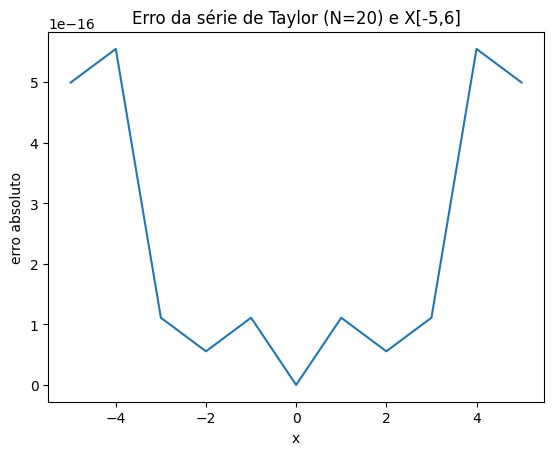

In [83]:
N_fixo = 20
x_amplo = np.arange(-5, 6, dtype=float)

aproximacao = np.array([cosseno_otimizado(v, N_fixo) for v in x_amplo])
erro = np.abs(np.cos(x_amplo) - aproximacao)

plt.plot(x_amplo, erro)
plt.xlabel('x')
plt.ylabel('erro absoluto')
plt.title(f'Erro da série de Taylor (N={N_fixo}) e X[-5,6]')
plt.show()

Com tudo isso, podemos chegar em várias conclusões. A série de Taylor do cosseno converge para todos os números reais de x, porém ela só coincidirá (tendo um N pequeno) com a função original cos(x) built-in quando x=0.

Conforme o valor de x vai sendo alterado, a série de Taylor começa a ter uma maior margem de erro se comparada à função original do cosseno, ultrapassando até mesmo o intervalo de -1 e 1. Isso, entretanto, pode ser contornado com o aumento da precisão com N. Se o valor de x for diferente de 0, o valor de N deve ser maior para compensar esse aumento e perseguir a precisão desejada com a função cos(x).